# September-Effect -- is September really the market's worst month?
### The most famous calendar omen on Wall Street, tested honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Every late summer the financial press dusts off the same warning: **September is the stock market's worst month** -- the one calendar month with a negative long-run average return. It even has a sibling slogan, *'Sell in May and go away.'* This notebook asks the only questions that matter: is the September drag actually real, and -- even if it is -- could you ever make money dodging it?

> **This is the plain-language layer.** Want the Newey-West t-stat, the permutation distribution, and the sub-period persistence check? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from september_effect import data, strategy as st

def _have_cache():
    try:
        data.fetch_sp500_monthly()
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("Shiller cache present:", HAVE_REAL)

# Frozen real-tape headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n_total=912, n_sep=76, n_other=836,
    sep_mean_pct=0.0, other_mean_pct=0.79, gap_pct=-0.79,
    sep_up_rate=0.579, all_up_rate=0.627,
    hac_t_sep=0.0, hac_t_gap=-1.926, welch_t=-1.807, welch_p=0.0743, perm_p=0.0345,
    bt_buyhold_ann_pct=8.253, bt_strat_gross_ann_pct=8.326,
    bt_strat_net_ann_pct=8.226, bt_gross_edge_pp=0.073, bt_net_edge_pp=-0.027,
    oct_mean_pct=-0.063, year_start=1950, year_end=2025,
)


Shiller cache present: True


## The answer first

| Question | Answer |
|---|---|
| Is September's average return really negative/flat? | **Almost exactly flat:** **+0.00%/mo** vs **+0.79%/mo** for every other month -- a real **-0.79pp/mo** gap. |
| Is that gap statistically solid? | **Borderline.** Newey-West *t* = **-1.93** -- it leans negative but does *not* clear the robust |t| >= 2 bar. |
| Is September actually the *worst* month? | **No** -- in this 1950-2025 window **October** is marginally worse (**-0.06%/mo**). September is the famous one, not the worst. |
| Could you trade it? | **No.** Sitting out September gains **+0.07pp/yr gross** -- and goes **negative net** of the two trades a year and taxes it costs. |

> September really is a soft month -- but the drag is small, statistically borderline, and worth essentially nothing once you try to trade it.

## 1 - The claim

> *"September is the worst month for stocks. On average the S&P 500 actually loses money in September -- it is the only month with a negative long-run average return. Smart money lightens up before Labor Day."*

This is folklore with real academic pedigree: the 'September effect' (and its cousin the Halloween / 'Sell in May' indicator) has been documented across decades and across many countries. Unlike the Super Bowl indicator, there is no obvious data-snooping origin -- September genuinely is soft. The interesting question is *how* soft, and whether 'soft' is the same thing as 'tradable.'

## 2 - So what?

If September carried a reliable, large negative premium, the fix would be trivial: spend one month a year in cash. That's the dream version of a calendar anomaly -- a free lunch you can put in your calendar app years ahead.

The honest version is more interesting. A real-but-tiny seasonal can be both academically true *and* completely useless to a trader, because the edge is smaller than the costs of harvesting it. September is the textbook case.

## 3 - How would we even know?

Three traps to avoid:

1. **The base-rate trap.** The S&P rises in ~63% of *all* months. So 'September is down' has to be measured against the fact that most months are up -- the right comparison is September vs the **pooled other-month** mean, not against zero in a vacuum.
2. **Serial correlation.** Monthly equity returns are mildly autocorrelated, which inflates a naive t-stat. We use a **Newey-West (HAC)** t-stat, which corrects for this -- and the robust bar for calling a signal REAL is |t| >= 2.
3. **One month a year.** With 76 years of data there are only **76 Septembers**. That is a small sample, and a single bad September (1974, 2001, 2008) moves the average a lot.

We test on the Shiller S&P 500 monthly price series, 1950-2025 (912 months, 76 Septembers).

## 4 - The teardown -- let's actually look

**First, the monthly profile:** the average S&P price return for each calendar month, with September called out.

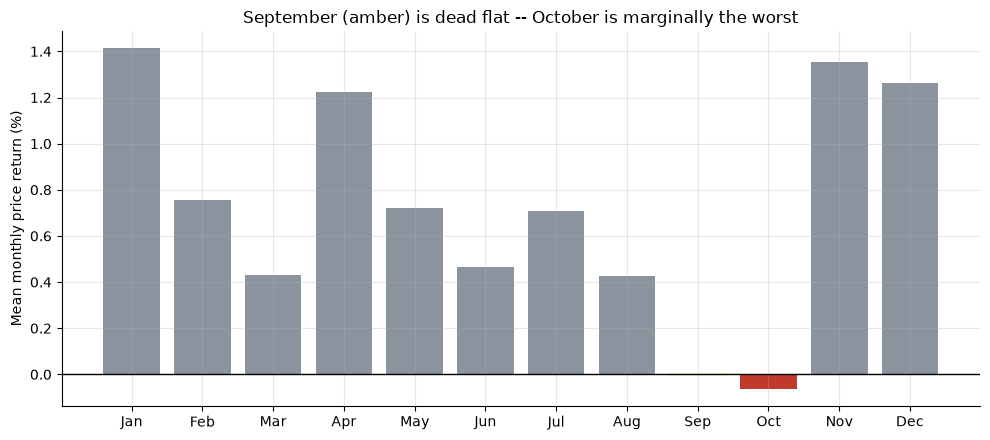

September mean: +0.000%/mo  |  October mean: -0.063%/mo
Every other month averages clearly positive; September stalls out.


In [2]:
if HAVE_REAL:
    df = data.fetch_sp500_monthly()
    prof = st.monthly_profile(df)
    means = prof['mean_pct'].values
    labels = list(prof.index)
else:
    labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    means = [1.413,0.754,0.430,1.224,0.720,0.465,0.707,0.426,
             R['sep_mean_pct'],R['oct_mean_pct'],1.352,1.262]

colors = [RED if m < 0.05 else GREY for m in means]
fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(labels, means, color=colors)
bars[8].set_color(AMBER)  # September
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean monthly price return (%)')
ax.set_title('September (amber) is dead flat -- October is marginally the worst')
plt.tight_layout(); plt.show()
print(f"September mean: {means[8]:+.3f}%/mo  |  October mean: {means[9]:+.3f}%/mo")
print('Every other month averages clearly positive; September stalls out.')

September sits at **+0.00%/mo** -- essentially flat -- while the other eleven months average comfortably positive. It is the famous laggard. (Note the honest twist: in this exact window **October** is the only month that is actually *negative*, at -0.06%/mo. 'September is the worst' is a slogan, not a fact.)

**The base-rate view -- September vs the pooled rest.**

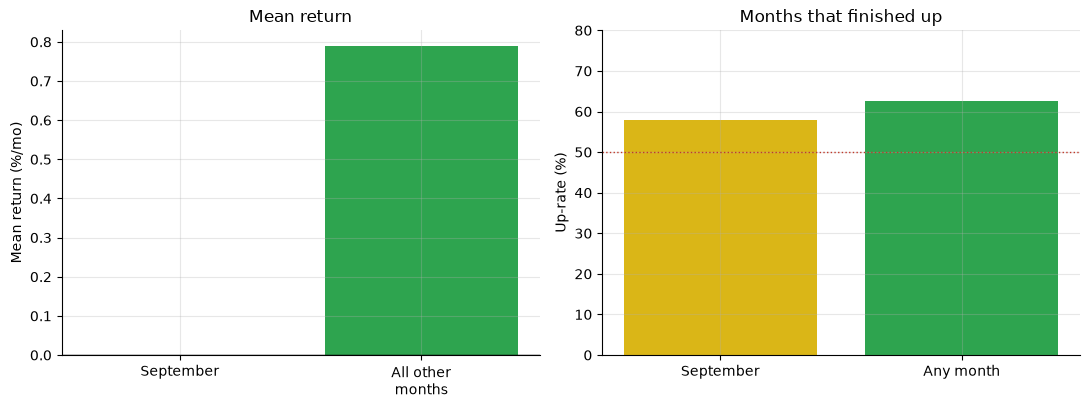

September up-rate: 57.9%  vs  any month: 62.7%
Mean gap: -0.79pp/mo


In [3]:
if HAVE_REAL:
    s = st.september_stats(df, n_permutations=2000, seed=290)
    sep_m, oth_m = s['sep_mean_pct'], s['other_mean_pct']
    sep_up, all_up = s['sep_up_rate'], s['all_up_rate']
else:
    sep_m, oth_m = R['sep_mean_pct'], R['other_mean_pct']
    sep_up, all_up = R['sep_up_rate'], R['all_up_rate']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].bar(['September','All other\nmonths'], [sep_m, oth_m],
            color=[AMBER, GREEN]); axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('Mean return (%/mo)'); axes[0].set_title('Mean return')
axes[1].bar(['September','Any month'], [sep_up*100, all_up*100],
            color=[AMBER, GREEN])
axes[1].axhline(50, c=RED, ls=':', lw=1)
axes[1].set_ylabel('Up-rate (%)'); axes[1].set_title('Months that finished up')
axes[1].set_ylim(0, 80)
plt.tight_layout(); plt.show()
print(f'September up-rate: {sep_up:.1%}  vs  any month: {all_up:.1%}')
print(f'Mean gap: {sep_m-oth_m:+.2f}pp/mo')

September finished up only **57.9%** of the time vs **62.7%** for an average month -- and its mean return runs **0.79pp/mo below** the rest. So the drag is real in the sample. The question the quants notebook settles is whether 76 Septembers are enough to call it *statistically* real.

## 5 - The verdict

- **Signal -- Weak.** September genuinely lags by **-0.79pp/mo** and the one-sided permutation test flags it (p = **0.03**), but the serial-correlation-robust Newey-West *t* = **-1.93** falls just short of the |t| >= 2 bar. Real-leaning, not robustly proven.
- **Tradability -- Mirage.** Avoiding September gains a microscopic **+0.07pp/yr** gross and turns **negative** once you pay for two trades a year and the taxes on realising the dodge. There is no money here.
- **Honest footnote.** The drag is **price-only**; September pays a roughly normal dividend, so the total-return gap is even smaller. And September isn't even the worst month in this window -- October is.

## 6 - Could you actually trade it?

The natural rule: hold the S&P all year *except* September, when you sit in cash. Here's what that buys you.

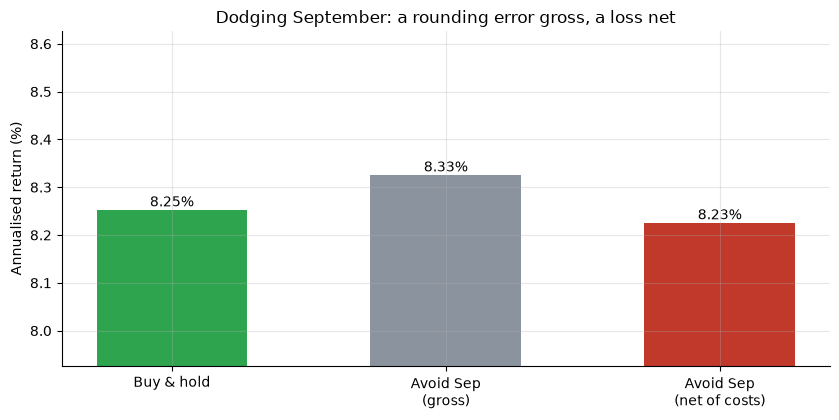

Buy & hold:        8.253%/yr
Avoid Sep (gross): 8.326%/yr  (edge +0.073pp)
Avoid Sep (net):   8.226%/yr  (edge -0.027pp)


In [4]:
if HAVE_REAL:
    bt = st.avoid_september_backtest(df, one_way_bps=5.0)
    bh, gross, net = bt['buyhold_ann_pct'], bt['strat_gross_ann_pct'], bt['strat_net_ann_pct']
else:
    bh, gross, net = R['bt_buyhold_ann_pct'], R['bt_strat_gross_ann_pct'], R['bt_strat_net_ann_pct']

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['Buy & hold','Avoid Sep\n(gross)','Avoid Sep\n(net of costs)'],
              [bh, gross, net], color=[GREEN, GREY, RED], width=0.55)
ax.set_ylabel('Annualised return (%)')
ax.set_title('Dodging September: a rounding error gross, a loss net')
ax.set_ylim(min(bh,net)-0.3, max(bh,gross)+0.3)
for b, v in zip(bars, [bh, gross, net]):
    ax.annotate(f'{v:.2f}%', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Buy & hold:        {bh:.3f}%/yr')
print(f'Avoid Sep (gross): {gross:.3f}%/yr  (edge {gross-bh:+.3f}pp)')
print(f'Avoid Sep (net):   {net:.3f}%/yr  (edge {net-bh:+.3f}pp)')

Gross, avoiding September adds **+0.07pp/yr** -- a rounding error. Net of just two trades a year at 5 bps one-way it is **negative**, and we haven't even charged the capital-gains tax that selling every August would trigger on a taxable account. The soft month is real; the trade is a mirage.

## 7 - Going further

- **The positive control:** the companion notebook plants a known September drag in a synthetic tape and shows the same test recovers it cleanly -- so the borderline real result is about the *market and sample size*, not a broken method.
- **The sibling seasonals:** the broader autumn / 'Sell in May' family lives in the October-effect and Halloween-indicator studies; September is the single-month slice.

*Think September is a tradable omen? Fork this, add the risk-free rate to the cash leg and a realistic tax model, and show a net edge that clears costs. That's the bar -- and a 0.07pp/yr gross edge doesn't get close.*